# A hypergraph exploration

CC-BY Amaury Minino and James B. Wilson

This notebook explores a hypergraph using Dleto.

First need to load Julia

In [ ]:
## Uncomment if you do not have iJulia installed
# using Pkg
# Pkg.add("IJulia")
# This installs Julia's Jupyter kernel without Python dependencies
# println("IJulia installed! Restart VS Code and select Julia kernel.")

# Ensure Julia kernel is properly recognized  
# This notebook requires Julia kernel for execution and export
using IJulia
println("Julia kernel is active!")
println("Julia version: ", VERSION) # Fix Jupyter/Julia setup - Install IJulia for Julia notebooks


Next we load Dleto.

In [ ]:
include("../Dleto.jl") 

Now let us load a hypergraph tensor.


In [ ]:
hypgraph_ten = loadTensorFromFile("Hypergraph-Tensor.txt")

We can better visualize this using 3D plotting software.


In [ ]:
plotTensor(hypgraph_ten)

In [ ]:
strata = toSurfaceTensor(hypgraph_ten)
plotTensor(strata.tensor)

In [ ]:
curve = toCurveTensor(hypgraph_ten)
plotTensor(curve.tensor)

## Making a hypergraph

A hyper graph is a set of subsets.  We can provide that as a matrix of 0,1 values where the columns are the enumeration of the domain and each row is the incidence relation of being in the subset.  For example 
$$\begin{bmatrix} 1 & 0 & 1 & 1\\ 0 & 1 & 1 & 1 \end{bmatrix}$$
is a hypergraph on \(1,2,3,4\) with hyperedges $\{1,3,4\}$ and $\{2,3,4\}$.

Let us create this in code.  

In [ ]:
hypgraph_small = [ 1 0 1 1; 
                   0 1 1 1 ]
small_ten = createTensorFromIncidence3(hypgraph_small)

In [ ]:
plotTensor(small_ten)

Now for something bigger.

In [ ]:
using Random
using SparseArrays

v = 75; e=50;
# Create a random 0-1 matrix with 30 columns, 20 rows, and exactly 3 nonzeros per row
m = zeros(Int, e,v)
for i in 1:e
    cols = randperm(v)[1:3]  # Randomly select 3 columns
    m[i, cols] .= 1
end
println("Random hyper graph on ", v, " vertices, ", e, " edges")
m

In [ ]:
asTen = createTensorFromIncidence3(m)
plotTensor(asTen)

In [ ]:
strat = toSurfaceTensor(asTen)
plotTensor(strat.tensor, 0.05)

In [ ]:
plotTensor(strat.tensor, 0.1)

In [ ]:
curve = toCurveTensor(asTen)
plotTensor(curve.tensor)

In [ ]:
face = toFaceCurveTensor(asTen)
plotTensor(face.tensor)

Now for real world data from
    Simplicial closure and higher-order link prediction.
    Austin R. Benson, Rediet Abebe, Michael T. Schaub, Ali Jadbabaie, and Jon Kleinberg.
    Proceedings of the National Academy of Sciences (PNAS), 2018. 

In [5]:
#import Pkg; Pkg.add("MatrixMarket")
using IJulia
# println("Julia kernel is active!")
# println("Julia version: ", VERSION)
include("../Dleto.jl") 
using MatrixMarket
fdaData = MatrixMarket.mmread("FDA_rows_sum_3_top_15_vertices_cleaned.mtx")
size(fdaData,2)
fdaTen = createTensorFromIncidence3(fdaData)
# plotTensor(fdaTen)
# strata = toSurfaceTensor(fdaTen)
# plotTensor(strata.tensor)
# curve = toCurveTensor(hypgraph_ten)
# plotTensor(curve.tensor)
# face = toFaceCurveTensor(asTen)
# plotTensor(face.tensor)

Dleto.jl loaded successfully.


13×13×13 Array{Float16, 3}:
[:, :, 1] =
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  1.0  0.0  1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  1.0  1.0  0.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  1.0  1.0  1.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  1.0  1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

[:, :, 2] =
 0.0  0.0  1.0  1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0

Plotting 234 points with value-proportional sizes...


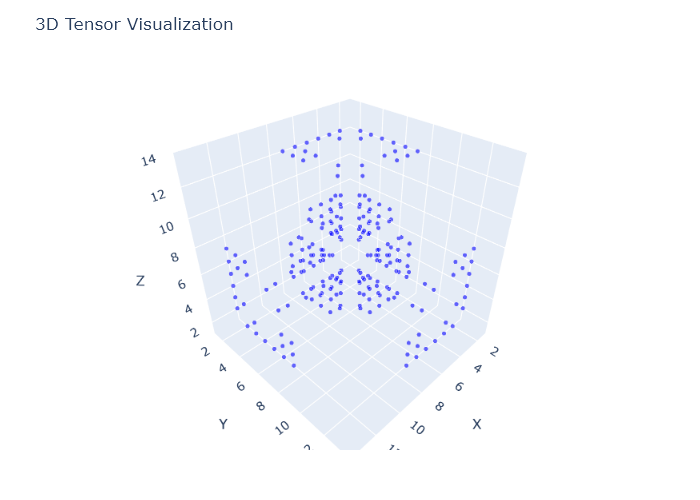

In [ ]:
plotTensor(fdaTen)



	Building linear system...
	Number of blocks: (1, 3)
	Number of variables: 273
	Sizes: (273, 2197)
Number of coordinates: 2197
loops to do: 6591
  0.003533 seconds (6.79 k allocations: 5.085 MiB)

	Computing singular vectors for (273, 2197)...
	
eigens[1] = [-2.3391547591171117e-14, -3.223609665308753e-15, 2.6458954083524868e-15, 1.861344577806293e-14, 0.6315078143826871, 0.6752563361961312, 0.6752563361961386, 1.1570337566672455, 1.3772934433383681, 1.4192755797286045, 2.376891514515807, 2.3768915145158114, 3.209147930548223, 3.209147930548227, 4.437692532308807, 4.4376925323088265, 4.4376925323088425, 4.554798723427116, 4.571424738029649, 4.571424738029673]
  0.085050 seconds (8.46 k allocations: 1.006 MiB)

	Extracting matrices...
  0.000008 seconds (2 allocations: 1.484 KiB)
  0.000002 seconds (2 allocations: 1.484 KiB)
  0.000002 seconds (2 allocations: 1.484 KiB)
Plotting 626 points with value-proportional sizes...


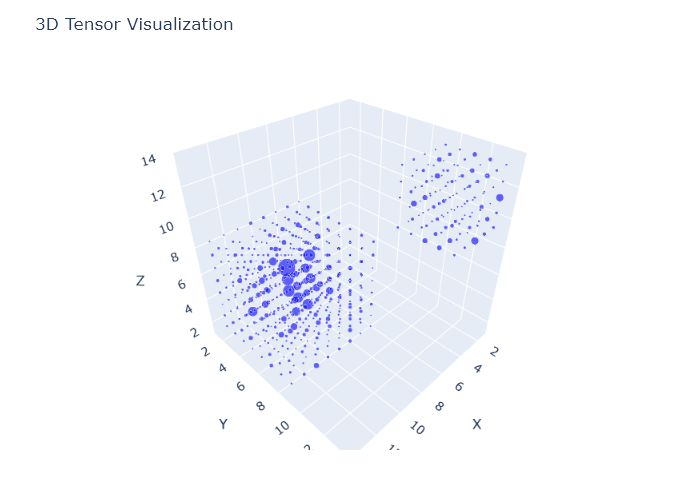

In [ ]:
strata = toSurfaceTensor(fdaTen)
plotTensor(strata.tensor)


	Number of blocks: (3, 3)
	Number of variables: 273
	Sizes: (273, 6591)
Number of coordinates: 2197
loops to do: 19773
eigens[1] = [-3.225486003079661e-14, 4.341323971175594e-14, 1.3505126723922922, 1.6005822251146173, 1.6005822251147717, 4.753783029031591, 6.263839868494976, 6.263839868495008, 6.41829586109645, 8.875385064617516, 8.875385064617639, 8.875385064617674, 9.142849476059373, 9.64218330839947, 9.693861065315174, 9.786383846797762, 9.786383846797786, 10.470501186724071, 10.78377126410827, 11.120962818184424]
Plotting 626 points with value-proportional sizes...


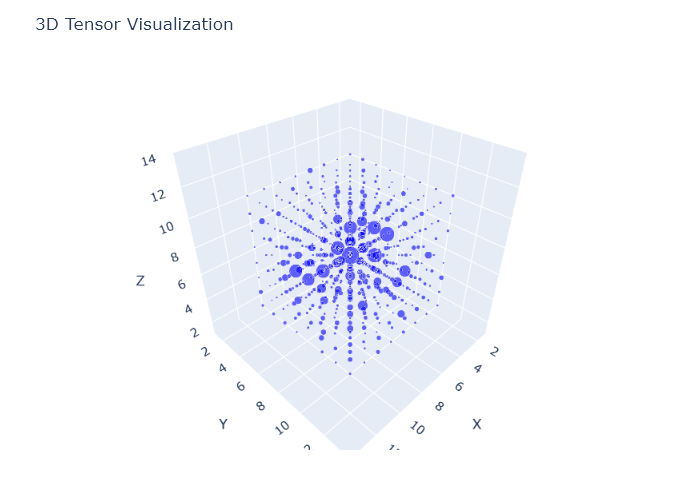

In [ ]:
curve = toCurveTensor(fdaTen)
plotTensor(curve.tensor)


	Number of blocks: (1, 2)
	Number of variables: 182
	Sizes: (182, 2197)
Number of coordinates: 2197
loops to do: 4394
eigens[1] = [2.489781429223967e-14, 7.069891134047127e-14, 0.6752563361962407, 0.8434424439927628, 2.3768915145158758, 2.607575868621154, 3.20914793054804, 4.437692532308754, 4.437692532308864, 4.571424738029677, 4.693451188770057, 4.821091654199711, 4.84693053265757, 4.999999999999998, 5.235250593362048, 5.300248052717296, 5.391885632054071, 5.56048140909216, 5.811402035307448, 5.811402035307475]
Plotting 623 points with value-proportional sizes...


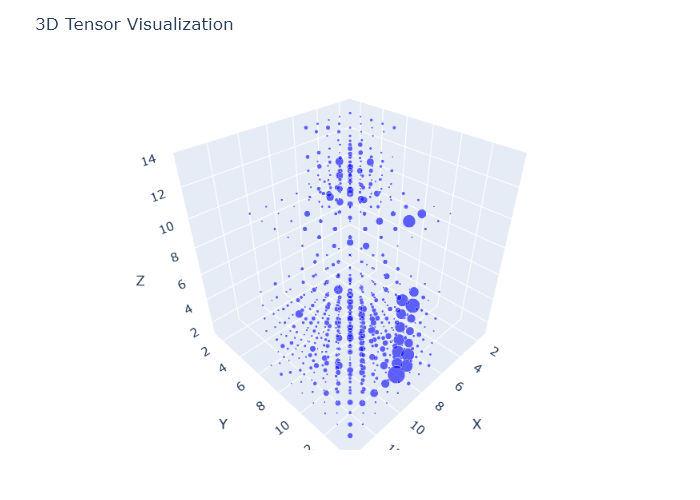

In [10]:
face = toFaceCurveTensor(fdaTen)
plotTensor(face.tensor)